## Discover data

In [27]:
import pandas as pd

In [ ]:
df = pd.read_csv('../data/pre-owned cars.csv')

print("Shape:", df.shape)

display(df.head())

df.info()

display(df.describe())

display(df.describe(include="object"))

df.isna().sum()

Shape: (2806, 15)


,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

,make_year,engine_capacity(CC),km_driven,price,overall_cost
count,2805.000000,2688.000000,2805.000000,2.806000e+03,2805.000000
mean,2018.181105,1259.027530,49215.477362,1.342522e+06,13495.022816
std,2.945293,254.504798,26626.932696,3.554669e+07,6040.809220
min,2010.000000,624.000000,450.000000,1.630000e+05,4039.000000
25%,2016.000000,1194.000000,28540.000000,4.350000e+05,9267.000000
50%,2018.000000,1197.000000,45695.000000,5.940000e+05,12145.000000
75%,2021.000000,1462.000000,68182.000000,8.140000e+05,15760.000000
max,2024.000000,2694.000000,143991.000000,1.883558e+09,47338.000000


,brand,model,transmission,reg_year,fuel_type,ownership,has_insurance,spare_key,reg_number,title
count,2805,2805,2805,720,2805,2805,2805,2805,2805,2805
unique,15,818,2,140,4,3,1,2,157,1530
top,Maruti,Baleno DELTA PETROL 1.2,Manual,01-07-2021,Petrol,1st owner,True,No,KA05,2017 Maruti Baleno DELTA PETROL 1.2
freq,925,48,1925,17,2373,2045,2805,2052,165,14


brand                     1
model                     1
transmission              1
make_year                 1
reg_year               2086
fuel_type                 1
engine_capacity(CC)     118
km_driven                 1
ownership                 1
price                     0
overall_cost              1
has_insurance             1
spare_key                 1
reg_number                1
title                     1
dtype: int64

## Clean data

In [29]:
df.dropna(subset=["brand", "model", "transmission", "make_year", "fuel_type", "km_driven", "ownership"])
df['price'].describe()

count    2.806000e+03
mean     1.342522e+06
std      3.554669e+07
min      1.630000e+05
25%      4.350000e+05
50%      5.940000e+05
75%      8.140000e+05
max      1.883558e+09
Name: price, dtype: float64

In [30]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Remove rows without core features
    required_columns = [
        "brand",
        "model",
        "transmission",
        "make_year",
        "fuel_type",
        "km_driven",
        "ownership",
        "price",
    ]

    df.dropna(subset=required_columns)

    # Drop columns that are not useful for baseline model
    df = df.drop(columns=["reg_year", "has_insurance", "title"], errors="ignore")

    # Fill missing engine capacity
    df["engine_capacity(CC)"] = df["engine_capacity(CC)"].fillna(
        df["engine_capacity(CC)"].median()
    )

    df = df[(df['price'] >= 100_000) & (df['price'] <= 3_000_000 )]
    df['car_age'] = 2024 - df['make_year']

    return df
    

In [31]:
df_clean = clean_data(df)

print(df_clean.shape)
display(df_clean.head())
display(df_clean.describe())
display(df_clean.isna().sum())

(2805, 13)


,brand,model,transmission,make_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,spare_key,reg_number,car_age
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,No,HR26,4.0
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,Petrol,1591.0,66936.0,1st owner,786000,15359.0,No,DL7C,6.0
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,No,HR29,2.0
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,Yes,DL4C,1.0
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,Diesel,1498.0,23480.0,1st owner,887000,16883.0,No,UP14,3.0


,make_year,engine_capacity(CC),km_driven,price,overall_cost,car_age
count,2805.000000,2805.000000,2805.000000,2.805000e+03,2805.000000,2805.000000
mean,2018.181105,1256.440285,49215.477362,6.715002e+05,13495.022816,5.818895
std,2.945293,249.447031,26626.932696,3.311789e+05,6040.809220,2.945293
min,2010.000000,624.000000,450.000000,1.630000e+05,4039.000000,0.000000
25%,2016.000000,1197.000000,28540.000000,4.350000e+05,9267.000000,3.000000
50%,2018.000000,1197.000000,45695.000000,5.940000e+05,12145.000000,6.000000
75%,2021.000000,1451.000000,68182.000000,8.140000e+05,15760.000000,8.000000
max,2024.000000,2694.000000,143991.000000,2.487000e+06,47338.000000,14.000000


brand                  0
model                  0
transmission           0
make_year              0
fuel_type              0
engine_capacity(CC)    0
km_driven              0
ownership              0
price                  0
overall_cost           0
spare_key              0
reg_number             0
car_age                0
dtype: int64

In [32]:
numerical = [
    "car_age",
    "engine_capacity(CC)",
    "km_driven",
    "overall_cost",
    "price"
]

df_clean[numerical].corr(numeric_only=True)

,car_age,engine_capacity(CC),km_driven,overall_cost,price
car_age,1.000000,-0.038864,0.557251,-0.473183,-0.598748
engine_capacity(CC),-0.038864,1.000000,0.128252,0.607175,0.575385
km_driven,0.557251,0.128252,1.000000,-0.225087,-0.293768
overall_cost,-0.473183,0.607175,-0.225087,1.000000,0.966033
price,-0.598748,0.575385,-0.293768,0.966033,1.000000


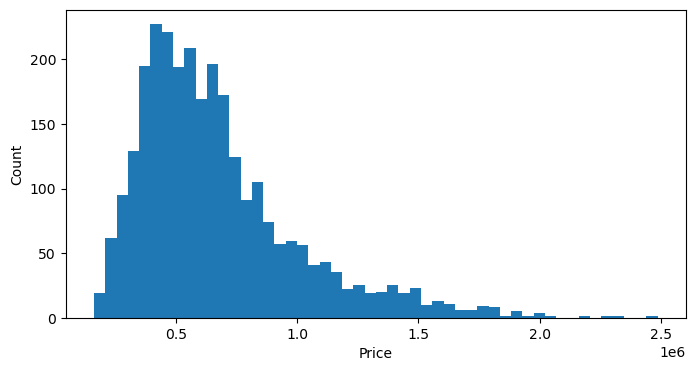

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df_clean["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [34]:
df_clean[["price", "overall_cost"]].head(20)

,price,overall_cost
0,1231000,23431.0
1,786000,15359.0
2,1489000,28349.0
3,1227000,23355.0
4,887000,16883.0
5,796000,15561.0
6,813000,15475.0
7,728000,14228.0
8,2322000,44197.0
9,766000,14977.0


In [35]:
(df_clean["price"] / df_clean["overall_cost"]).describe()

count    2805.000000
mean       49.282097
std         6.171722
min        11.247637
25%        51.123091
50%        51.151124
75%        52.512798
max        52.565029
dtype: float64

## Train model

In [36]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42
)

print(df_train.shape)
print(df_test.shape)

(2244, 13)
(561, 13)


In [37]:
categorical = [
    "brand",
    "model",
    "transmission",
    "fuel_type",
    "ownership",
    "spare_key",
    "reg_number",
]

numerical = [
    "car_age",
    "engine_capacity(CC)",
    "km_driven",
]

target = "price"

In [40]:
from sklearn.feature_extraction import DictVectorizer

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
test_dicts = df_test[categorical + numerical].to_dict(
    orient="records"
)

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

y_train = df_train[target].values
y_test = df_test[target].values


In [43]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [44]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 128769.88200344935
MAE: 93931.74723611395
R²: 0.839407361607599


In [45]:
numerical = [
    "car_age",
    "engine_capacity(CC)",
    "km_driven",
    "overall_cost",
]

In [46]:
from sklearn.feature_extraction import DictVectorizer

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
test_dicts = df_test[categorical + numerical].to_dict(
    orient="records"
)

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

y_train = df_train[target].values
y_test = df_test[target].values

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)


RMSE: 47456.63871291223
MAE: 35598.37004962756
R²: 0.9781882261198066


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [48]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R²:", r2_rf)

RMSE: 19629.03621672843
MAE: 6423.938867556905
R²: 0.9962684008077549


In [55]:
categorical_no_model = [
    "brand",
    "transmission",
    "fuel_type",
    "ownership",
    "spare_key",
    "reg_number",
]

In [59]:
train_dicts = df_train[categorical_no_model + numerical].to_dict(orient='records')
test_dicts = df_test[categorical_no_model + numerical].to_dict(orient='records')

dv_no_model = DictVectorizer()
X_train_no_model = dv_no_model.fit_transform(train_dicts)
X_test_no_model = dv_no_model.transform(test_dicts)


rf_no_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_no_model.fit(X_train_no_model, y_train)

y_pred_rf_no_model = rf_no_model.predict(X_test_no_model)

print("RMSE:", root_mean_squared_error(y_test, y_pred_rf_no_model))
print("MAE:", mean_absolute_error(y_test, y_pred_rf_no_model))
print("R²:", r2_score(y_test, y_pred_rf_no_model))

RMSE: 20010.400509325944
MAE: 6779.224707562461
R²: 0.996121992898228


In [61]:
df_train = df_clean[df_clean["make_year"] <= 2021].copy()
df_test = df_clean[df_clean["make_year"] > 2021].copy()

print(df_train.shape)
print(df_test.shape)

(2380, 13)
(425, 13)


In [62]:
train_dicts = df_train[categorical_no_model + numerical].to_dict(orient="records")
test_dicts = df_test[categorical_no_model + numerical].to_dict(orient="records")

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

y_train = df_train["price"].values
y_test = df_test["price"].values

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

RMSE: 54485.32543284268
MAE: 14328.720483985284
R²: 0.9816434959643678


## Add mlflow

In [70]:
import mlflow
import mlflow.sklearn

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "used-car-price-prediction"

In [71]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)


2026/06/11 13:49:03 INFO mlflow.tracking.fluent: Experiment with name 'used-car-price-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/julia/Desktop/Projects/used-car-price-prediction-mlops/mlruns/1', creation_time=1781153343596, experiment_id='1', last_update_time=1781153343596, lifecycle_stage='active', name='used-car-price-prediction', tags={}, trace_location=None, workspace='default'>

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

categorical = [
    "brand",
    "model",
    "transmission",
    "fuel_type",
    "ownership",
    "spare_key",
    "reg_number",
]

numerical = [
    "car_age",
    "engine_capacity(CC)",
    "km_driven",
    # "overall_cost",
]

target = "price"

df_train = df_clean[df_clean['make_year'] <= 2021].copy()
df_test = df_clean[df_clean['make_year'] > 2021].copy()

train_dicts = df_train[categorical + numerical].to_dict(orient="records")
test_dicts = df_test[categorical + numerical].to_dict(orient="records")

dv = DictVectorizer()

X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

y_train = df_train[target].values
y_test = df_test[target].values

params = {
    "n_estimators": 100,
    "max_depth": 15,
    "random_state": 42,
    "n_jobs": -1,
}

with mlflow.start_run():
    mlflow.set_tag("developer", "julia")
    mlflow.set_tag("model_type", "random_forest")
    mlflow.set_tag("model_feature_included", "true")
    mlflow.set_tag("leakage_features_excluded", "overall_cost")
    
    mlflow.log_param("train_condition", "make_year <= 2021")
    mlflow.log_param("test_condition", "make_year > 2021")
    mlflow.log_param("categorical_features", categorical)
    mlflow.log_param("numerical_features", numerical)
    mlflow.log_params(params)

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    os.makedirs("models", exist_ok=True)

    with open('models/dv.pkl', "wb") as f_out:
        pickle.dump(dv, f_out)

    mlflow.log_artifact("models/dv.pkl", artifact_path="preprocessor")
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model"
    )

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)

2026/06/11 14:02:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/11 14:02:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 230040.43382565884
MAE: 156520.0985674454
R²: 0.6727804586530639
🏃 View run fortunate-conch-263 at: http://127.0.0.1:5000/#/experiments/1/runs/39a25dd5fb9349118815858aacc4f820
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


The feature overall_cost improved performance dramatically (R² 0.67 → 0.98). Further analysis showed a very strong correlation with the target (0.966), suggesting potential target leakage. Therefore, the feature was excluded from the production model.